# Implied Equity Duration — Dechow, Sloan & Soliman (2002)

**Clean-surplus, accounting-based implementation. Annual data. Finite-horizon CFs plus residual level perpetuity.**

## 1. Setup and Paper Goal

### DSS (2002) Logic

Dechow, Sloan & Soliman (2002) construct *implied equity duration* by decomposing the observed market value of equity into:

1. **Finite-horizon discounted cash flows** (horizons $h = 1, \ldots, H$),
2. **A residual terminal value** — inferred as the difference between observed market equity and the discounted finite-horizon CFs.

Cash flows are defined via **clean surplus accounting**:
$$
CF_{t+h} = E_{t+h} - (BE_{t+h} - BE_{t+h-1}) = BE_{t+h-1}(ROE_{t+h} - g_{t+h})
$$
where $E$ = net income, $BE$ = book equity, $ROE$ = return on equity, $g$ = book equity growth.

Future ROE and equity growth are **forecast via mean-reverting AR(1) processes**:
$$
E_t[ROE_{t+h}] = r + \rho_{\text{roe}}^h (ROE_t - r)
$$
$$
E_t[g_{t+h}] = \bar{g} + \rho_g^h (YG_t - \bar{g})
$$
where $r$ is the cost of equity, $\bar{g}$ is long-run growth, and $YG_t$ is the sales growth rate (used as the predictor for future book equity growth).

The **terminal residual** is treated as a **level perpetuity** (no growth) starting at $H+1$:
$$
TV_{\text{residual}} = ME_t - \sum_{h=1}^{H} \frac{E_t[CF_{t+h}]}{(1+r)^h}
$$

**Macaulay-style implied duration:**
$$
D_{it} = \frac{1}{ME_t}\left[
\sum_{h=1}^{H} h \cdot \frac{E_t[CF_{t+h}]}{(1+r)^h}
+ TV_{\text{residual}} \cdot \left(H + \frac{1+r}{r}\right)
\right]
$$
The terminal term $H + (1+r)/r$ is the exact Macaulay duration of a level perpetuity starting at $H+1$, measured from $t=0$.

### What is exact DSS-style vs. what is an approximation

| Component | DSS-exact | Approximation here |
|---|---|---|
| Clean-surplus CF definition | ✓ | — |
| ROE mean-reversion forecast | ✓ | — |
| Sales growth as growth predictor | ✓ | Missing sales → use BEG fallback |
| BE lag path (DSS linear approx.) | ✓ (baseline) | Recursive alternative also shown |
| Level perpetuity terminal | ✓ | — |
| CAPM cost of equity | ✓ (baseline) | Constant-$r$ also shown |
| Annual fiscal-year data | ✓ | Input is quarterly; aggregated to annual |

**⚠ Sales data note:** `euro500_implied.parquet` does not contain a sales/revenue field. Sales is sourced from `euro500_netpayout.parquet` and merged by firm-year. If sales are unavailable for a firm-year, the notebook falls back to using book equity growth ($BEG_t$) instead of sales growth ($YG_t$) as the growth predictor. This is flagged in the output and is a deviation from the DSS paper.

In [55]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 80)

from project_paths import DATA_DIR, BASE_DIR
from plot_style import COLORS, set_global_plot_style, style_axes

set_global_plot_style()

GRAPHS_DIR = BASE_DIR / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

def save_parquet(df: pd.DataFrame, name: str) -> None:
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}  ({len(df):,} rows x {len(df.columns)} cols)")

def load_parquet(name: str) -> pd.DataFrame:
    return pd.read_parquet(DATA_DIR / f"{name}.parquet")

print("Setup complete.")
print(f"DATA_DIR : {DATA_DIR}")
print(f"BASE_DIR : {BASE_DIR}")

Setup complete.
DATA_DIR : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate
BASE_DIR : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data


## 2. Load Data and Inspect Structure

In [56]:
# ── Load primary input ──────────────────────────────────────────────────────
implied_path   = DATA_DIR / "euro500_implied.parquet"
netpayout_path = DATA_DIR / "euro500_netpayout.parquet"

for p in [implied_path, netpayout_path]:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

df_raw = pd.read_parquet(implied_path)
np_raw = pd.read_parquet(netpayout_path)

print("=" * 60)
print("euro500_implied.parquet")
print("=" * 60)
print(f"  Shape   : {df_raw.shape}")
print(f"  Columns : {list(df_raw.columns)}")
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
print(f"  Date range: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"  Unique firms: {df_raw['firm_id'].nunique():,}")
print()
print("dtype summary:")
display(df_raw.dtypes.to_frame("dtype"))

print()
print("Numeric coverage (non-null share):")
display(df_raw.select_dtypes(include="number").notna().mean().round(3).to_frame("coverage"))

print()
print("Sample rows:")
display(df_raw.head(3))

euro500_implied.parquet
  Shape   : (56500, 29)
  Columns : ['date', 'formation_date', 'effective_date', 'quarter', 'RIC', 'name', 'firm_id', 'hq_country', 'hq_code', 'trbc_sector', 'trbc_sector_code', 'mcap_eur', 'RIC_current', 'ISIN', 'SEDOL', 'first_trade_date', 'ipo_date', 'FreeFloat', 'FreeFloatPct', 'Volume', 'shares_outstanding', 'PriceClose', 'InstrumentType', 'Currency', 'rank_mcap', 'beta', 'market_risk_free_rate_annual', 'Net_Income', 'Book_Equity']
  Date range: 1997-12-31 → 2025-12-31
  Unique firms: 1,248

dtype summary:


,dtype
date,datetime64[ns]
formation_date,datetime64[ns]
effective_date,datetime64[ns]
quarter,object
RIC,object
name,string[python]
firm_id,string[python]
hq_country,string[python]
hq_code,string[python]
trbc_sector,string[python]



Numeric coverage (non-null share):


,coverage
mcap_eur,1.0000
FreeFloat,0.9750
FreeFloatPct,0.9750
Volume,0.9760
shares_outstanding,0.9930
PriceClose,0.9930
rank_mcap,1.0000
beta,0.9340
market_risk_free_rate_annual,0.9820
Net_Income,0.9580



Sample rows:


,date,formation_date,effective_date,quarter,RIC,name,firm_id,hq_country,hq_code,trbc_sector,trbc_sector_code,mcap_eur,RIC_current,ISIN,SEDOL,first_trade_date,ipo_date,FreeFloat,FreeFloatPct,Volume,shares_outstanding,PriceClose,InstrumentType,Currency,rank_mcap,beta,market_risk_free_rate_annual,Net_Income,Book_Equity
0,1997-12-31,1997-12-31,1998-01-01,1998Q1,DTEGn.DE,Deutsche Telekom AG,FIRM0000557,Germany,DE,Technology,57,46211813784.3400,DTEGn.DE,DE0005557508,5842359,1996-11-18,2000-01-24,501789960,18.2888,0,2699473550.4010,17.1188,Ordinary Shares,EUR,1,NaN,NaN,1690330959.2347,23215719157.5955
1,1997-12-31,1997-12-31,1998-01-01,1998Q1,SIMG.F,Simona AG,FIRM0000907,Germany,DE,Basic Materials,51,69537617.4497,SIM0.F,DE000A3E5CP0,4809946,1996-11-12,1990-05-04,6000000,100.0000,<NA>,<NA>,<NA>,Ordinary Shares,EUR,342,NaN,NaN,<NA>,<NA>
2,1997-12-31,1997-12-31,1998-01-01,1998Q1,NSCP.PA,NSC Groupe SA,FIRM0000347,France,FR,Industrials,52,71544471.1938,ALNSC.PA,FR0000064529,4617611,1991-03-25,1991-03-25,411540,53.3774,10,594804.7743,120.2823,Ordinary Shares,EUR,341,NaN,NaN,<NA>,<NA>


In [57]:
print("=" * 60)
print("euro500_netpayout.parquet")
print("=" * 60)
print(f"  Shape   : {np_raw.shape}")
print(f"  Columns : {list(np_raw.columns)}")
np_raw["date"] = pd.to_datetime(np_raw["date"], errors="coerce")
print(f"  Date range: {np_raw['date'].min().date()} → {np_raw['date'].max().date()}")
print(f"  Unique firms: {np_raw['firm_id'].nunique():,}")
print()
display(np_raw.head(3))

euro500_netpayout.parquet
  Shape   : (16872, 13)
  Columns : ['firm_id', 'date', 'BE', 'assets', 'debt', 'Sales', 'NetIncome', 'GrossProfit', 'Cogs', 'Dividends', 'Buybacks', 'CashSTInvst', 'mcap_eur']
  Date range: 1995-12-30 → 2025-09-30
  Unique firms: 1,125



,firm_id,date,BE,assets,debt,Sales,NetIncome,GrossProfit,Cogs,Dividends,Buybacks,CashSTInvst,mcap_eur
0,FIRM0000001,1998-11-30,92670119.5912,201941375.2729,54100816.5331,296097820.3627,15384772.7052,145027942.1013,151069878.2614,10021320.8714,0.0000,20117801.6494,138569059.7810
1,FIRM0000001,1999-11-30,104237075.8195,264407949.5662,101319133.0535,305313856.5213,15307056.3393,148917850.7334,156396005.7878,<NA>,<NA>,39481959.0660,121992375.0000
2,FIRM0000001,2000-11-30,108772234.8057,265103817.8165,99152278.0610,379503331.0666,14892398.6236,184504276.9566,194999054.1100,11046972.3851,<NA>,21139362.8281,192793450.0000


In [58]:
# ── Column mapping table ─────────────────────────────────────────────────────
# Robustly identify key fields across possible naming conventions.

def _first_match(candidates, cols):
    return next((c for c in candidates if c in cols), None)

all_implied_cols = set(df_raw.columns)
all_np_cols     = set(np_raw.columns)

FIELD_SPECS = [
    # (internal_name, source, candidates, required)
    ("firm_id",   "implied",   ["firm_id", "company_id", "ds_code"],          True),
    ("date",      "implied",   ["date", "effective_date"],                      True),
    ("name",      "implied",   ["name"],                                        False),
    ("isin",      "implied",   ["ISIN", "isin"],                                False),
    ("sector",    "implied",   ["trbc_sector", "sector", "gics_sector"],        False),
    ("mcap_eur",  "implied",   ["mcap_eur", "market_cap", "MarketCap"],         True),
    ("price",     "implied",   ["PriceClose", "price", "Price"],                False),
    ("shares",    "implied",   ["shares_outstanding", "shares"],                False),
    ("beta",      "implied",   ["beta", "Beta"],                                False),
    ("rf",        "implied",   ["market_risk_free_rate_annual", "rf_estr_annual"], False),
    # Accounting — primary source is netpayout
    ("NI_col",    "netpayout", ["NetIncome", "Net_Income", "net_income"],        True),
    ("BE_col",    "netpayout", ["BE", "Book_Equity", "book_equity"],             True),
    ("Sales_col", "netpayout", ["Sales", "sales", "Revenue", "revenue",
                                 "net_sales", "total_revenue"],                  False),
]

resolved = {}
rows = []
for internal, src, candidates, required in FIELD_SPECS:
    pool = all_implied_cols if src == "implied" else all_np_cols
    match = _first_match(candidates, pool)
    resolved[internal] = match
    status = "FOUND" if match else ("MISSING (required!)" if required else "missing (optional)")
    rows.append({"internal": internal, "source": src,
                 "original_column": match or "—", "status": status})

mapping_df = pd.DataFrame(rows)
print("Column mapping (original → internal):")
display(mapping_df.to_string(index=False))

# Raise on required fields
missing_req = [r["internal"] for r in rows if "required!" in r["status"]]
if missing_req:
    raise KeyError(f"Required columns not found: {missing_req}")

# Sales availability flag — prominently reported
SALES_AVAILABLE = resolved["Sales_col"] is not None
if SALES_AVAILABLE:
    print(f"\n✓ Sales column found in netpayout: '{resolved['Sales_col']}'")
    print("  → Growth predictor: YG_t (sales growth). Paper-near DSS implementation.")
else:
    print("\n⚠ WARNING: No sales/revenue column found in euro500_netpayout.parquet.")
    print("  → Falling back to BEG_t (book equity growth) as growth predictor.")
    print("  → This is a deviation from DSS (2002). Results are less paper-near.")

Column mapping (original → internal):


' internal    source              original_column status\n  firm_id   implied                      firm_id  FOUND\n     date   implied                         date  FOUND\n     name   implied                         name  FOUND\n     isin   implied                         ISIN  FOUND\n   sector   implied                  trbc_sector  FOUND\n mcap_eur   implied                     mcap_eur  FOUND\n    price   implied                   PriceClose  FOUND\n   shares   implied           shares_outstanding  FOUND\n     beta   implied                         beta  FOUND\n       rf   implied market_risk_free_rate_annual  FOUND\n   NI_col netpayout                    NetIncome  FOUND\n   BE_col netpayout                           BE  FOUND\nSales_col netpayout                        Sales  FOUND'


✓ Sales column found in netpayout: 'Sales'
  → Growth predictor: YG_t (sales growth). Paper-near DSS implementation.


## 3. Data Preparation

**Aggregation strategy:** `euro500_implied.parquet` is quarterly. We aggregate to annual by taking the latest quarterly observation per firm-calendar-year. This approximates fiscal year-end market data (valid for December fiscal year-end firms, which dominate the European universe).

**Accounting data:** Book equity, net income, and sales are sourced from `euro500_netpayout.parquet`, which contains annual fiscal-year observations. These are merged to the annual implied panel by firm-year.

**ROE and BEG** are constructed from current and lagged book equity and net income.

In [59]:
# ── Step 1: Aggregate implied (quarterly) → annual ───────────────────────────
df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["firm_id"] = df["firm_id"].astype(str).str.strip()
df["year"] = df["date"].dt.year

# Latest quarterly obs per firm-year (proxy for fiscal year-end market data)
df_annual = (
    df.sort_values(["firm_id", "date"])
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
    .copy()
)

# Keep only relevant columns from implied
keep_implied = ["firm_id", "year", "date"]
for field in ["name", "isin", "sector", "mcap_eur", "price", "shares", "beta", "rf"]:
    col = resolved.get(field)
    if col and col in df_annual.columns:
        keep_implied.append(col)
df_annual = df_annual[keep_implied].copy()

# Standardize internal names
rename_implied = {}
for field, col in resolved.items():
    if col and col in df_annual.columns and field not in ("firm_id", "date"):
        rename_implied[col] = field
df_annual = df_annual.rename(columns=rename_implied)

print(f"Implied annual panel: {len(df_annual):,} rows, "
      f"{df_annual['firm_id'].nunique():,} firms, "
      f"years {df_annual['year'].min()}–{df_annual['year'].max()}")

Implied annual panel: 15,551 rows, 1,248 firms, years 1997–2025


In [60]:
# ── Step 2: Annual accounting from netpayout ────────────────────────────────
np_df = np_raw.copy()
np_df["date"] = pd.to_datetime(np_df["date"], errors="coerce")
np_df["firm_id"] = np_df["firm_id"].astype(str).str.strip()
np_df["year"] = np_df["date"].dt.year

NI_COL    = resolved["NI_col"]
BE_COL    = resolved["BE_col"]
SALES_COL = resolved["Sales_col"]  # may be None

np_keep = ["firm_id", "year", NI_COL, BE_COL]
if SALES_COL:
    np_keep.append(SALES_COL)

np_annual = (
    np_df[np_keep]
    .sort_values(["firm_id", "year"])
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
    .rename(columns={NI_COL: "Net_Income", BE_COL: "Book_Equity",
                     **({SALES_COL: "Sales"} if SALES_COL else {})})
    .copy()
)

for col in ["Net_Income", "Book_Equity"] + (["Sales"] if SALES_COL else []):
    np_annual[col] = pd.to_numeric(np_annual[col], errors="coerce")

print(f"Netpayout annual: {len(np_annual):,} rows, "
      f"{np_annual['firm_id'].nunique():,} firms, "
      f"years {np_annual['year'].min()}–{np_annual['year'].max()}")
print(f"Net_Income coverage : {np_annual['Net_Income'].notna().mean():.1%}")
print(f"Book_Equity coverage: {np_annual['Book_Equity'].notna().mean():.1%}")
if SALES_COL:
    print(f"Sales coverage      : {np_annual['Sales'].notna().mean():.1%}")

Netpayout annual: 16,858 rows, 1,125 firms, years 1995–2025
Net_Income coverage : 98.2%
Book_Equity coverage: 99.3%
Sales coverage      : 98.0%


In [61]:
# ── Step 3: Merge implied + netpayout ────────────────────────────────────────
# Mapping: netpayout fiscal year t → implied calendar year t
# Assumption: most European firms have December fiscal year-ends,
# so fiscal year t ends in December of year t, matching Q4 market data.
panel = df_annual.merge(np_annual, on=["firm_id", "year"], how="left")
panel = panel.sort_values(["firm_id", "year"]).reset_index(drop=True)

print(f"Merged panel: {len(panel):,} rows, {panel['firm_id'].nunique():,} firms")
print(f"Net_Income match rate : {panel['Net_Income'].notna().mean():.1%}")
print(f"Book_Equity match rate: {panel['Book_Equity'].notna().mean():.1%}")

Merged panel: 15,551 rows, 1,248 firms
Net_Income match rate : 87.7%
Book_Equity match rate: 89.0%


In [62]:
# ── Step 4: Construct state variables ────────────────────────────────────────

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Market equity: prefer mcap_eur, fallback price*shares
panel["ME_t"] = _to_num(panel.get("mcap_eur", np.nan))
if "price" in panel.columns and "shares" in panel.columns:
    fallback_me = _to_num(panel["price"]) * _to_num(panel["shares"])
    panel["ME_t"] = panel["ME_t"].where(panel["ME_t"].notna() & (panel["ME_t"] > 0), fallback_me)
    n_fallback_me = ((panel["ME_t"] == fallback_me) & fallback_me.notna()).sum()
    print(f"ME_t: {n_fallback_me:,} rows filled via price×shares fallback")
panel["ME_t"] = panel["ME_t"].astype(float)  # ensure plain float64

# Accounting: ensure numeric
panel["Book_Equity"] = _to_num(panel["Book_Equity"])
panel["Net_Income"]  = _to_num(panel["Net_Income"])
if "Sales" in panel.columns:
    panel["Sales"] = _to_num(panel["Sales"])

# Lagged accounting variables (within firm)
for col in ["Book_Equity", "Net_Income"] + (["Sales"] if "Sales" in panel.columns else []):
    panel[f"{col}_lag1"] = panel.groupby("firm_id")[col].shift(1)

# Core state variables
BE_t   = panel["Book_Equity"]
BE_L1  = panel["Book_Equity_lag1"]
NI_t   = panel["Net_Income"]

# ROE_t = Net_Income_t / Book_Equity_{t-1}
# Force plain float64 to avoid pandas nullable-float TypeError in apply loops
panel["BE_t"]   = BE_t.astype(float)
panel["BE_lag1"] = BE_L1.astype(float)
# Re-bind local vars to float64 columns so np.where conditions work cleanly
BE_t  = panel["BE_t"]
BE_L1 = panel["BE_lag1"]
NI_t  = NI_t.astype(float)
panel["ROE_t"]  = np.where(BE_L1 > 0, NI_t / BE_L1, np.nan)

# BEG_t = (BE_t - BE_{t-1}) / BE_{t-1}
panel["BEG_t"] = np.where(BE_L1 > 0, (BE_t - BE_L1) / BE_L1, np.nan)

# YG_t = (Sales_t - Sales_{t-1}) / Sales_{t-1}  (if available)
if "Sales" in panel.columns:
    Sales_t  = panel["Sales"]
    Sales_L1 = panel["Sales_lag1"]
    panel["YG_t"] = np.where(
        Sales_L1.notna() & (Sales_L1 > 0) & Sales_t.notna(),
        (Sales_t - Sales_L1) / Sales_L1,
        np.nan
    )
else:
    panel["YG_t"] = np.nan

# Discount rate columns (filled after parameter block)
panel["rf"]   = _to_num(panel.get("rf", np.nan))
panel["beta"] = _to_num(panel.get("beta", np.nan))

# Book-to-market and price-to-book
panel["BM_t"]  = np.where(panel["ME_t"] > 0, BE_t / panel["ME_t"], np.nan)
panel["PB_t"]  = np.where(BE_t > 0, panel["ME_t"] / BE_t, np.nan)

print("\nState variables constructed:")
state_cols = ["ME_t", "BE_t", "BE_lag1", "ROE_t", "BEG_t", "YG_t", "rf", "beta", "BM_t"]
display(panel[state_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(4))

ME_t: 5,603 rows filled via price×shares fallback

State variables constructed:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ME_t,15551.0000,8582412150.8766,19821389900.4417,4172034.9762,29111227.0345,129052409.2319,713803783.1275,2155902782.2033,7044043220.1474,41180761284.7350,94870728996.0247,368302706239.9990
BE_t,13839.0000,5221065996.2970,11866200809.5441,-9951000000.0000,15125383.1085,75006650.7658,400208500.0000,1290558000.0000,4109384000.0000,25439870000.0000,61008260000.0000,168404000000.0000
BE_lag1,13751.0000,5231953576.9834,11880937812.0862,-9951000000.0000,15422681.6979,76465000.0000,402472000.0000,1296300000.0000,4125100000.0000,25510609000.0000,61005500000.0000,168404000000.0000
ROE_t,12372.0000,0.2295,11.0025,-210.3822,-0.4095,-0.0945,0.0654,0.1303,0.2113,0.4450,0.9638,1194.9021
BEG_t,12571.0000,0.4806,22.0376,-117.3333,-0.4855,-0.1896,-0.0012,0.0690,0.1611,0.5595,1.9464,2046.6006
YG_t,12438.0000,0.7752,31.8585,-13.7842,-0.6226,-0.2134,-0.0119,0.0603,0.1560,0.5427,1.7719,2197.9244
rf,15025.0000,0.0162,0.0175,-0.0059,-0.0057,-0.0056,-0.0007,0.0193,0.0330,0.0419,0.0491,0.0516
beta,14298.0000,0.9121,0.6325,-6.4667,-0.1985,0.0751,0.4977,0.8439,1.2452,1.9415,2.7679,8.6818
BM_t,13839.0000,0.7199,0.7534,-8.2879,0.0372,0.1240,0.3216,0.5491,0.9099,1.8172,3.5028,22.1973


In [63]:
# ── Step 5: Quality screens with sample-loss diagnostics ────────────────────
n0 = len(panel)
screens = [
    ("Positive market equity (ME_t > 0)",  panel["ME_t"] > 0),
    ("Positive lagged book equity (BE_lag1 > 0)", panel["BE_lag1"] > 0),
    ("Finite net income",                  panel["Net_Income"].notna()),
    ("Finite ROE_t",                       panel["ROE_t"].notna()),
    ("Finite BEG_t",                       panel["BEG_t"].notna()),
]

diag_rows = []
running_mask = pd.Series(True, index=panel.index)
diag_rows.append({"screen": "(All observations)", "n": n0, "n_dropped": 0, "pct_remaining": 100.0})

for label, mask in screens:
    n_before = running_mask.sum()
    running_mask = running_mask & mask
    n_after = running_mask.sum()
    diag_rows.append({
        "screen": label,
        "n": n_after,
        "n_dropped": n_before - n_after,
        "pct_remaining": 100.0 * n_after / n0
    })

diag_df = pd.DataFrame(diag_rows)
print("Sample loss after sequential quality screens:")
display(diag_df.to_string(index=False))

panel_clean = panel.loc[running_mask].copy()
print(f"\nClean panel: {len(panel_clean):,} rows, "
      f"{panel_clean['firm_id'].nunique():,} firms, "
      f"years {panel_clean['year'].min()}–{panel_clean['year'].max()}")

Sample loss after sequential quality screens:


'                                   screen     n  n_dropped  pct_remaining\n                       (All observations) 15551          0       100.0000\n        Positive market equity (ME_t > 0) 15551          0       100.0000\nPositive lagged book equity (BE_lag1 > 0) 13672       1879        87.9172\n                        Finite net income 12372       1300        79.5576\n                             Finite ROE_t 12372          0        79.5576\n                             Finite BEG_t 12325         47        79.2554'


Clean panel: 12,325 rows, 911 firms, years 1998–2025


## 4. Parameter Choices

All parameters are defined in one block. Robustness variants in Section 9 override individual entries.

In [64]:
# ============================================================
# PARAMETER BLOCK — modify here, propagates to all sections
# ============================================================

PARAMS = {
    # Forecast horizon (years)
    # DSS (2002) use H=10 in their Table 3 baseline.
    "H": 10,

    # ROE persistence: controls mean-reversion speed toward r.
    # DSS (2002) Table 2 Panel A estimate ≈ 0.57. We use 0.57 as baseline.
    # Interpretation: about half the ROE gap closes each year.
    "rho_roe": 0.57,

    # Growth persistence: controls mean-reversion speed of equity/sales growth.
    # DSS (2002) Table 2 Panel A estimate = 0.24. Paper value used as baseline.
    "rho_g": 0.24,

    # Long-run (steady-state) equity growth mean.
    # DSS (2002) use 6% (Ibbotson long-run nominal GDP growth).
    "g_bar": 0.06,

    # Equity risk premium (annualized) for CAPM cost of equity
    # Standard academic consensus for Euro area: 5%.
    "ERP": 0.05,

    # Constant cost of equity — DSS (2002) baseline: 12% cross-sectional constant.
    # Using a constant r ensures duration variation comes only from CF timing,
    # not from cross-sectional differences in discount rates.
    "r_constant": 0.12,

    # ROE winsorization bounds (prevent extreme forecasts)
    "ROE_lo": -0.50,
    "ROE_hi":  0.50,

    # Growth winsorization bounds
    "BEG_lo": -0.50,
    "BEG_hi":  0.50,

    # Duration output winsorization (flag extreme values)
    "D_max": 100.0,
}

# ── Estimate g_bar from sample median sales growth (if available) ────────────
if "YG_t" in panel_clean.columns and panel_clean["YG_t"].notna().any():
    g_bar_empirical = float(panel_clean["YG_t"].median())
    print(f"Sample median sales growth (YG_t): {g_bar_empirical:.4f}")
    print(f"Using g_bar = {PARAMS['g_bar']:.3f} (DSS paper) vs empirical {g_bar_empirical:.4f}")
    PARAMS["g_bar_empirical"] = g_bar_empirical
elif panel_clean["BEG_t"].notna().any():
    g_bar_empirical = float(panel_clean["BEG_t"].median())
    print(f"Sample median BEG_t (fallback g_bar estimate): {g_bar_empirical:.4f}")
    PARAMS["g_bar_empirical"] = g_bar_empirical
else:
    PARAMS["g_bar_empirical"] = PARAMS["g_bar"]

print("\nBaseline parameters:")
for k, v in PARAMS.items():
    print(f"  {k:<20} = {v}")

Sample median sales growth (YG_t): 0.0604
Using g_bar = 0.060 (DSS paper) vs empirical 0.0604

Baseline parameters:
  H                    = 10
  rho_roe              = 0.57
  rho_g                = 0.24
  g_bar                = 0.06
  ERP                  = 0.05
  r_constant           = 0.12
  ROE_lo               = -0.5
  ROE_hi               = 0.5
  BEG_lo               = -0.5
  BEG_hi               = 0.5
  D_max                = 100.0
  g_bar_empirical      = 0.060419747321451736


In [65]:
# ── Construct cost of equity r_it ────────────────────────────────────────────
# DSS (2002) baseline: constant r = 12% cross-sectional.
# Rationale: a common discount rate ensures duration variation comes from
# CF timing differences only, not from cross-sectional discount rate differences.
# CAPM r_it is retained and used in robustness variant A_CAPM_r.

ERP = PARAMS["ERP"]
r_const = PARAMS["r_constant"]  # 0.12 — DSS paper baseline

panel_clean = panel_clean.copy()

# Always compute CAPM r for use in robustness variant
panel_clean["r_capm"] = panel_clean["rf"] + panel_clean["beta"] * ERP

# flag_r_fallback: obs where CAPM rate is unavailable (kept for reference)
panel_clean["flag_r_fallback"] = panel_clean["r_capm"].isna()

# BASELINE r_it = constant 0.12 (DSS paper) for all observations
panel_clean["r_it"] = r_const

n_capm_avail = (~panel_clean["flag_r_fallback"]).sum()
n_total_r    = len(panel_clean)
print(f"Cost of equity (r_it):")
print(f"  Baseline r_it : {r_const:.0%} (DSS constant, applied to ALL {n_total_r:,} obs)")
print(f"  CAPM r_capm   : available for {n_capm_avail:,} obs ({n_capm_avail/n_total_r:.1%}) — used in robustness only")
print()
display(panel_clean[["r_it", "r_capm"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4))

# Winsorize ROE and BEG for forecasting robustness
panel_clean["ROE_t_w"] = panel_clean["ROE_t"].clip(
    PARAMS["ROE_lo"], PARAMS["ROE_hi"]
)
panel_clean["BEG_t_w"] = panel_clean["BEG_t"].clip(
    PARAMS["BEG_lo"], PARAMS["BEG_hi"]
)
if "YG_t" in panel_clean.columns:
    panel_clean["YG_t_w"] = panel_clean["YG_t"].clip(
        PARAMS["BEG_lo"], PARAMS["BEG_hi"]
    ).astype(float)
else:
    panel_clean["YG_t_w"] = np.nan

print("\nWinsorized state variables (ROE_t_w, BEG_t_w, YG_t_w):")
display(panel_clean[["ROE_t_w", "BEG_t_w", "YG_t_w"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(4))

Cost of equity (r_it):
  Baseline r_it : 12% (DSS constant, applied to ALL 12,325 obs)
  CAPM r_capm   : available for 12,214 obs (99.1%) — used in robustness only



,r_it,r_capm
count,12325.0000,12214.0000
mean,0.1200,0.0607
std,0.0000,0.0352
min,0.1200,-0.1582
1%,0.1200,-0.0045
5%,0.1200,0.0125
25%,0.1200,0.0368
50%,0.1200,0.0578
75%,0.1200,0.0806
95%,0.1200,0.1185



Winsorized state variables (ROE_t_w, BEG_t_w, YG_t_w):


,ROE_t_w,BEG_t_w,YG_t_w
count,12325.0000,12325.0000,12249.0000
mean,0.1390,0.0861,0.0772
std,0.1563,0.1810,0.1873
min,-0.5000,-0.5000,-0.5000
1%,-0.4092,-0.4847,-0.5000
5%,-0.0943,-0.1889,-0.2121
50%,0.1303,0.0691,0.0604
95%,0.4438,0.5000,0.5000
99%,0.5000,0.5000,0.5000
max,0.5000,0.5000,0.5000


## 5. Forecasting Logic

Two implementations of the BE lag path:

**Version A — DSS linear approximation (baseline):**
$$E_t[BE_{t+h-1}] = \begin{cases} BE_t & h = 1 \\ BE_t\bigl(1 + \bar{g} + \rho_g^{h-1}(YG_t - \bar{g})\bigr) & h \geq 2 \end{cases}$$
This linearizes the BE path — equivalent to applying the single-period forecasted growth rate at horizon $h-1$ rather than compounding.

**Version B — Recursive compounding (robustness):**
$$E_t[BE_{t+h}] = E_t[BE_{t+h-1}] \cdot (1 + E_t[g_{t+h}])$$

Both produce the same clean-surplus expected CFs:
$$E_t[CF_{t+h}] = E_t[BE_{t+h-1}] \cdot (E_t[ROE_{t+h}] - E_t[g_{t+h}])$$

In [66]:
# ── Core forecasting functions ────────────────────────────────────────────────

def forecast_roe(ROE_t, r, rho_roe, H):
    """E_t[ROE_{t+h}] = r + rho_roe^h * (ROE_t - r), for h=1..H."""
    h_arr = np.arange(1, H + 1, dtype=float)
    return r + rho_roe ** h_arr * (ROE_t - r)


def forecast_growth(growth_t, g_bar, rho_g, H):
    """E_t[g_{t+h}] = g_bar + rho_g^h * (growth_t - g_bar), for h=1..H."""
    h_arr = np.arange(1, H + 1, dtype=float)
    return g_bar + rho_g ** h_arr * (growth_t - g_bar)


def be_lag_dss(BE_t, growth_t, g_bar, rho_g, H):
    """
    Version A: DSS linear approximation for E_t[BE_{t+h-1}], h=1..H.
    h=1 → BE_t (exact). h>=2 → BE_t * (1 + g_bar + rho_g^(h-1) * (growth_t - g_bar)).
    """
    path = np.empty(H, dtype=float)
    path[0] = BE_t  # h=1: known exactly
    for h in range(2, H + 1):
        path[h - 1] = BE_t * (1.0 + g_bar + rho_g ** (h - 1) * (growth_t - g_bar))
    return path


def be_lag_recursive(BE_t, growth_t, g_bar, rho_g, H):
    """
    Version B: Recursive BE path.
    be_lag[h-1] = E_t[BE_{t+h-1}], compounded from BE_t.
    """
    path = np.empty(H, dtype=float)
    be = BE_t
    for h in range(1, H + 1):
        path[h - 1] = be  # lagged BE for period t+h CF
        g_h = g_bar + rho_g ** h * (growth_t - g_bar)
        be = be * (1.0 + g_h)
    return path


def forecast_cashflows(ROE_t, growth_t, BE_t, r, params, version="dss"):
    """
    Full forecast of expected clean-surplus CFs for h=1..H.

    Returns
    -------
    roe_hat, beg_hat, be_lag_path, cf_hat : np.ndarray of shape (H,)
    """
    H     = params["H"]
    rho_roe = params["rho_roe"]
    rho_g   = params["rho_g"]
    g_bar   = params["g_bar"]

    roe_hat = forecast_roe(ROE_t, r, rho_roe, H)
    beg_hat = forecast_growth(growth_t, g_bar, rho_g, H)

    if version == "dss":
        be_lag = be_lag_dss(BE_t, growth_t, g_bar, rho_g, H)
    elif version == "recursive":
        be_lag = be_lag_recursive(BE_t, growth_t, g_bar, rho_g, H)
    else:
        raise ValueError(f"version must be 'dss' or 'recursive', got '{version}'")

    cf_hat = be_lag * (roe_hat - beg_hat)
    return roe_hat, beg_hat, be_lag, cf_hat


print("Forecasting functions defined: forecast_roe, forecast_growth,")
print("  be_lag_dss, be_lag_recursive, forecast_cashflows.")

Forecasting functions defined: forecast_roe, forecast_growth,
  be_lag_dss, be_lag_recursive, forecast_cashflows.


Demo firm-year: GEA Group AG, 2013
  ROE_t=0.1303, growth_t=0.0429, r_it=0.1200
  BE_t=2,313,035,000



,horizon,E[ROE],E[BEG],E[BE_lag] DSS,E[BE_lag] Recursive,E[CF/BE0] DSS,E[CF/BE0] Recursive
0,1,0.1259,0.0559,1.0000,1.0000,0.0700,0.0700
1,2,0.1233,0.0590,1.0559,1.0559,0.0679,0.0679
2,3,0.1219,0.0598,1.0590,1.1182,0.0658,0.0695
3,4,0.1211,0.0599,1.0598,1.1850,0.0648,0.0725
4,5,0.1206,0.0600,1.0599,1.2561,0.0643,0.0762
5,6,0.1204,0.0600,1.0600,1.3314,0.0640,0.0804
6,7,0.1202,0.0600,1.0600,1.4113,0.0638,0.0850
7,8,0.1201,0.0600,1.0600,1.4960,0.0637,0.0899
8,9,0.1201,0.0600,1.0600,1.5857,0.0637,0.0952
9,10,0.1200,0.0600,1.0600,1.6809,0.0636,0.1009


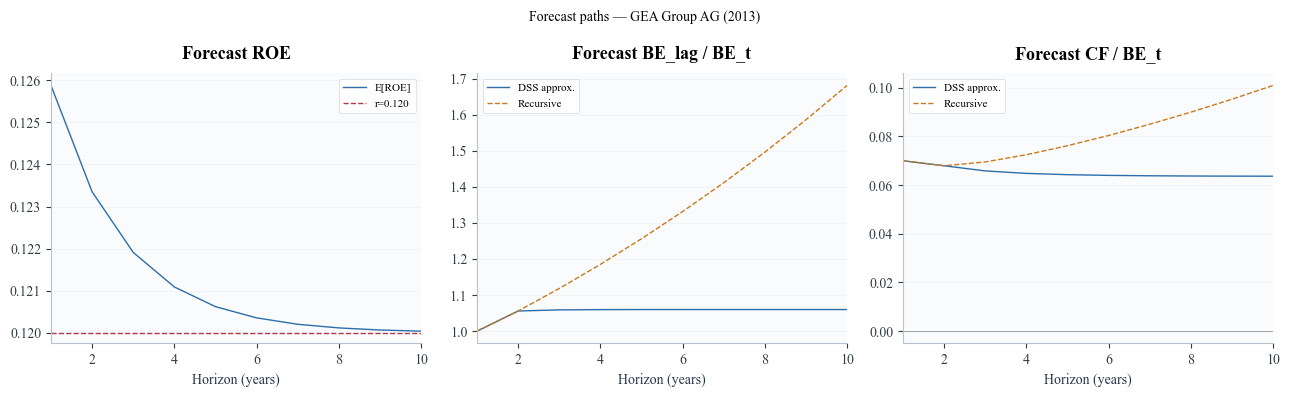

In [67]:
# ── Diagnostic: show example forecast paths for a median-like firm ───────────

# Pick the firm-year closest to panel medians for illustration
def _median_obs(df):
    from numpy import abs as nabs
    score = (
        nabs(df["ROE_t_w"] - df["ROE_t_w"].median()).fillna(999)
        + nabs(df["BEG_t_w"] - df["BEG_t_w"].median()).fillna(999)
        + nabs(df["r_it"] - df["r_it"].median()).fillna(999)
    )
    return df.loc[score.idxmin()]

demo = _median_obs(panel_clean)
growth_demo = demo["YG_t_w"] if pd.notna(demo.get("YG_t_w", np.nan)) else demo["BEG_t_w"]

r_demo   = float(demo["r_it"])
ROE_demo = float(demo["ROE_t_w"])
BEG_demo = float(demo["BEG_t_w"])
BE_demo  = float(demo["BE_t"])
growth_demo = float(growth_demo)

H_demo = PARAMS["H"]

roe_hat_A, beg_hat_A, be_lag_A, cf_A = forecast_cashflows(
    ROE_demo, growth_demo, BE_demo, r_demo, PARAMS, version="dss")
roe_hat_B, beg_hat_B, be_lag_B, cf_B = forecast_cashflows(
    ROE_demo, growth_demo, BE_demo, r_demo, PARAMS, version="recursive")

demo_path = pd.DataFrame({
    "horizon":    np.arange(1, H_demo + 1),
    "E[ROE]": roe_hat_A,
    "E[BEG]": beg_hat_A,
    "E[BE_lag] DSS":       be_lag_A / BE_demo,  # scaled to 1
    "E[BE_lag] Recursive": be_lag_B / BE_demo,
    "E[CF/BE0] DSS":       cf_A / BE_demo,
    "E[CF/BE0] Recursive": cf_B / BE_demo,
})

firm_label = demo.get("name", demo["firm_id"])
print(f"Demo firm-year: {firm_label}, {int(demo['year'])}")
print(f"  ROE_t={ROE_demo:.4f}, growth_t={growth_demo:.4f}, r_it={r_demo:.4f}")
print(f"  BE_t={BE_demo:,.0f}")
print()
display(demo_path.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
h = demo_path["horizon"]
axes[0].plot(h, demo_path["E[ROE]"], color=COLORS["blue"], label="E[ROE]")
axes[0].axhline(r_demo, color=COLORS["accent"], ls="--", lw=1, label=f"r={r_demo:.3f}")
axes[0].set_title("Forecast ROE"); axes[0].set_xlabel("Horizon (years)")
axes[0].legend(fontsize=8); style_axes(axes[0])

axes[1].plot(h, demo_path["E[BE_lag] DSS"],       color=COLORS["blue"],   label="DSS approx.")
axes[1].plot(h, demo_path["E[BE_lag] Recursive"],  color=COLORS["orange"], label="Recursive", ls="--")
axes[1].set_title("Forecast BE_lag / BE_t"); axes[1].set_xlabel("Horizon (years)")
axes[1].legend(fontsize=8); style_axes(axes[1])

axes[2].plot(h, demo_path["E[CF/BE0] DSS"],       color=COLORS["blue"],   label="DSS approx.")
axes[2].plot(h, demo_path["E[CF/BE0] Recursive"],  color=COLORS["orange"], label="Recursive", ls="--")
axes[2].axhline(0, color="grey", lw=0.5)
axes[2].set_title("Forecast CF / BE_t"); axes[2].set_xlabel("Horizon (years)")
axes[2].legend(fontsize=8); style_axes(axes[2])

plt.suptitle(f"Forecast paths — {firm_label} ({int(demo['year'])})", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Present Value and Terminal Residual

For each firm-year:
$$PV_{\text{forecast}} = \sum_{h=1}^{H} \frac{E_t[CF_{t+h}]}{(1+r)^h}$$
$$TV_{\text{residual}} = ME_t - PV_{\text{forecast}}$$

The terminal residual $TV_{\text{residual}}$ is treated as the **present value (at $t=0$) of a level perpetuity starting at $H+1$**. Observations with $TV_{\text{residual}} \leq 0$ imply that finite-horizon CFs alone exceed observed market value — economically, this flags firms where the DSS model is misspecified or accounting data is unreliable. We report rather than silently drop these.

In [68]:
# ── Core duration computation function ───────────────────────────────────────

def _sf(v, default=np.nan):
    """Safe float — converts pd.NA, None, or any missing to default."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return default


def compute_dss_duration(row, params, version="dss", use_sales_growth=True):
    """
    Compute DSS (2002) implied equity duration for a single firm-year.

    Parameters
    ----------
    version           : 'dss' (DSS linear approx) or 'recursive'
    use_sales_growth  : if True, use YG_t_w; else fall back to BEG_t_w

    Returns a pd.Series with duration metrics and diagnostic flags.
    """
    null_result = pd.Series({
        "pv_forecast":      np.nan,
        "pv_terminal":      np.nan,
        "tv_share":         np.nan,
        "implied_duration": np.nan,
        "modified_duration": np.nan,
        "dv01":             np.nan,
        "flag_neg_terminal": False,
        "flag_fallback_growth": False,
    })

    # Extract and validate inputs
    ME  = _sf(row.get("ME_t",   np.nan))
    BE  = _sf(row.get("BE_t",   np.nan))
    ROE = _sf(row.get("ROE_t_w", np.nan))
    BEG = _sf(row.get("BEG_t_w", np.nan))
    r   = _sf(row.get("r_it",   np.nan))
    YG  = _sf(row.get("YG_t_w", np.nan))

    if not all(np.isfinite(x) for x in [ME, BE, ROE, BEG, r]):
        return null_result
    if ME <= 0 or BE <= 0 or r <= 0:
        return null_result

    # Growth predictor
    flag_fallback = False
    if use_sales_growth and np.isfinite(YG):
        growth_pred = YG
    else:
        growth_pred = BEG
        flag_fallback = True

    # Forecast CFs
    _, beg_hat, be_lag, cf_hat = forecast_cashflows(
        ROE, growth_pred, BE, r, params, version=version
    )

    H     = params["H"]
    h_arr = np.arange(1, H + 1, dtype=float)
    disc  = (1.0 + r) ** (-h_arr)
    pv_cfs = cf_hat * disc

    PV_forecast  = float(np.sum(pv_cfs))
    PV_terminal  = ME - PV_forecast          # at t=0
    flag_neg_tv  = PV_terminal <= 0.0
    tv_share     = PV_terminal / ME

    # ── Duration ─────────────────────────────────────────────────────────────
    # Finite contribution
    finite_num = float(np.sum(h_arr * pv_cfs))

    # Terminal contribution:
    # PV_terminal is the PV at t=0 of the level perpetuity.
    # Duration of a level perpetuity starting at H+1 (from t=0) = H + (1+r)/r.
    D_perp = H + (1.0 + r) / r
    terminal_contrib = PV_terminal * D_perp

    D_it  = (finite_num + terminal_contrib) / ME
    D_mod = D_it / (1.0 + r)
    DV01  = D_mod * ME * 1e-4

    return pd.Series({
        "pv_forecast":       PV_forecast,
        "pv_terminal":       PV_terminal,
        "tv_share":          tv_share,
        "implied_duration":  D_it,
        "modified_duration": D_mod,
        "dv01":              DV01,
        "flag_neg_terminal": flag_neg_tv,
        "flag_fallback_growth": flag_fallback,
    })


print("compute_dss_duration() defined.")

compute_dss_duration() defined.


In [69]:
# ── Apply baseline duration computation ──────────────────────────────────────
print("Computing baseline DSS duration (version=recursive, r=12% constant)...")

dur_results = panel_clean.apply(
    compute_dss_duration,
    axis=1,
    params=PARAMS,
    version="recursive",
    use_sales_growth=True,
)

for col in dur_results.columns:
    panel_clean[col] = dur_results[col].values

print("Done.")
print(f"Valid implied_duration: {panel_clean['implied_duration'].notna().sum():,} "
      f"/ {len(panel_clean):,} ({panel_clean['implied_duration'].notna().mean():.1%})")

# ── Terminal residual diagnostics ────────────────────────────────────────────
n_neg_tv = int(panel_clean["flag_neg_terminal"].sum())
n_valid  = panel_clean["implied_duration"].notna().sum()
print(f"\nNegative terminal residual (TV_residual <= 0): {n_neg_tv:,} obs "
      f"({n_neg_tv/len(panel_clean):.1%} of clean panel)")
print(f"Fallback growth predictor used: {panel_clean['flag_fallback_growth'].sum():,} obs")

if n_neg_tv > 0:
    neg_tv = panel_clean[panel_clean["flag_neg_terminal"]]
    print(f"\nNegative TV firms: {neg_tv['firm_id'].nunique():,} unique")
    print("tv_share distribution for negative-TV obs:")
    display(neg_tv["tv_share"].describe().round(4))
    print("\nPossible causes: very high forecasted CFs (high ROE, positive growth),")
    print("or very low/depressed market equity relative to accounting fundamentals.")

# Define two samples
mask_pos_tv = panel_clean["flag_neg_terminal"] == False
panel_baseline = panel_clean[mask_pos_tv & panel_clean["implied_duration"].notna()].copy()
panel_diag     = panel_clean[panel_clean["implied_duration"].notna()].copy()  # includes neg TV

print(f"\nBaseline sample (positive TV, finite duration): {len(panel_baseline):,} obs")
print(f"Diagnostic sample (all finite duration)       : {len(panel_diag):,} obs")

Computing baseline DSS duration (version=recursive, r=12% constant)...
Done.
Valid implied_duration: 12,300 / 12,325 (99.8%)

Negative terminal residual (TV_residual <= 0): 218 obs (1.8% of clean panel)
Fallback growth predictor used: 76 obs

Negative TV firms: 99 unique
tv_share distribution for negative-TV obs:


count   218.0000
mean     -0.5921
std       0.7444
min      -5.4522
25%      -0.7715
50%      -0.3411
75%      -0.1259
max      -0.0000
Name: tv_share, dtype: float64


Possible causes: very high forecasted CFs (high ROE, positive growth),
or very low/depressed market equity relative to accounting fundamentals.

Baseline sample (positive TV, finite duration): 12,082 obs
Diagnostic sample (all finite duration)       : 12,300 obs


## 7. Implied Equity Duration

In [70]:
# ── Duration summary ─────────────────────────────────────────────────────────
print("Implied equity duration — baseline sample (positive TV):")
display(
    panel_baseline[["implied_duration", "modified_duration", "tv_share", "pv_forecast", "pv_terminal"]]
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .round(3)
)

print("\nImplied equity duration — full diagnostic sample:")
display(
    panel_diag["implied_duration"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(3)
)

# Fraction above D_max
D_max = PARAMS["D_max"]
n_extreme = (panel_baseline["implied_duration"] > D_max).sum()
print(f"\nObs with duration > {D_max:.0f}: {n_extreme:,} ({n_extreme/len(panel_baseline):.2%})")
print("These are retained but flagged via 'flag_duration_extreme'.")
panel_baseline["flag_duration_extreme"] = panel_baseline["implied_duration"] > D_max
panel_diag["flag_duration_extreme"]     = panel_diag["implied_duration"] > D_max

Implied equity duration — baseline sample (positive TV):


,implied_duration,modified_duration,tv_share,pv_forecast,pv_terminal
count,12082.0000,12082.0000,12082.0000,12082.0000,12082.0000
mean,15.5590,13.8920,0.7320,2282547406.3960,7129244439.9460
std,2.6520,2.3680,0.1790,5109964136.3530,17061410736.9890
min,4.4880,4.0070,0.0000,-5503264431.3700,1087992.8450
1%,7.1860,6.4160,0.1520,-52200519.0810,59590376.1890
5%,10.4610,9.3400,0.3820,34713559.4820,142374042.9730
10%,12.1670,10.8630,0.4970,67440295.3280,260133101.3750
25%,14.2710,12.7420,0.6420,195690427.9820,639973155.2110
50%,16.0510,14.3310,0.7680,582592004.2310,1846971903.5640
75%,17.2650,15.4160,0.8540,1789570887.4760,5833553045.5400



Implied equity duration — full diagnostic sample:


count   12300.0000
mean       15.2210
std         3.9230
min       -73.1890
1%          1.2510
5%          9.5420
25%        14.1370
50%        15.9990
75%        17.2440
95%        18.6310
99%        20.8880
max        41.1660
Name: implied_duration, dtype: float64


Obs with duration > 100: 0 (0.00%)
These are retained but flagged via 'flag_duration_extreme'.


## 8. Diagnostics and Validation

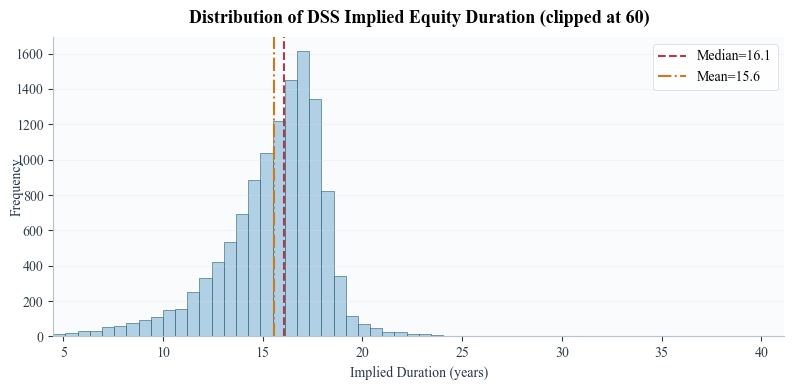

In [71]:
# ── Histogram of duration ────────────────────────────────────────────────────
D_plot = panel_baseline["implied_duration"].clip(upper=60)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(D_plot, bins=60, color=COLORS["blue_light"], edgecolor=COLORS["primary"], alpha=0.9)
ax.axvline(D_plot.median(), color=COLORS["accent"], lw=1.5, ls="--",
           label=f"Median={D_plot.median():.1f}")
ax.axvline(D_plot.mean(), color=COLORS["orange"], lw=1.5, ls="-.",
           label=f"Mean={D_plot.mean():.1f}")
ax.set_title("Distribution of DSS Implied Equity Duration (clipped at 60)")
ax.set_xlabel("Implied Duration (years)")
ax.set_ylabel("Frequency")
ax.legend()
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

By-year duration statistics:


' year    mean  median   n\n 1998 15.7106 16.2388 273\n 1999 15.9526 16.4477 350\n 2000 15.8480 16.4523 383\n 2001 15.9625 16.2109 383\n 2002 15.1508 15.2709 433\n 2003 15.7271 15.9021 429\n 2004 15.6228 15.9874 443\n 2005 15.8362 16.2810 446\n 2006 16.2505 16.7318 445\n 2007 15.8656 16.2973 460\n 2008 14.7027 14.9567 465\n 2009 15.6014 15.8303 472\n 2010 15.0455 15.5001 475\n 2011 14.7832 15.1236 456\n 2012 15.1177 15.4815 466\n 2013 15.8060 16.2262 474\n 2014 15.7958 16.2225 459\n 2015 15.9718 16.4063 476\n 2016 15.7006 16.3223 471\n 2017 15.9188 16.5343 478\n 2018 15.2542 15.7547 471\n 2019 15.6208 16.2314 480\n 2020 16.0032 16.6156 475\n 2021 15.7878 16.4687 476\n 2022 15.1618 16.0239 470\n 2023 15.2336 15.9695 468\n 2024 14.9555 15.4909 469\n 2025 15.6107 15.3583  36'

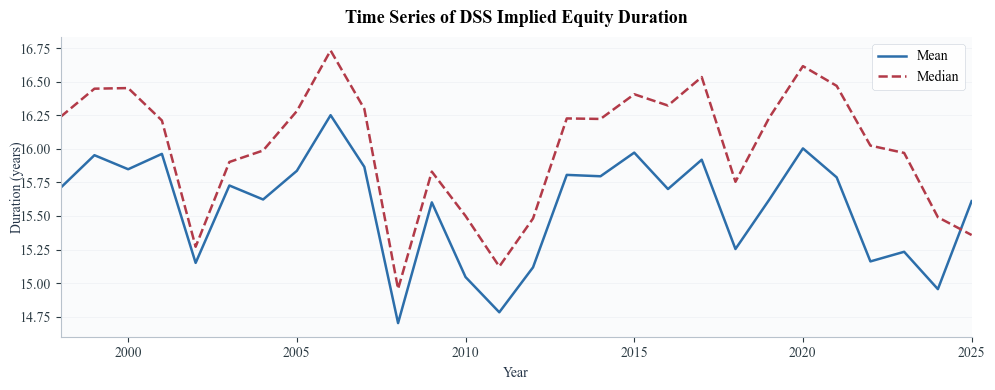

In [72]:
# ── By-year mean and median duration ────────────────────────────────────────
by_year = (
    panel_baseline.groupby("year")["implied_duration"]
    .agg(mean="mean", median="median", n="count")
    .reset_index()
)
print("By-year duration statistics:")
display(by_year.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_year["year"], by_year["mean"],   color=COLORS["blue"],   lw=1.8, label="Mean")
ax.plot(by_year["year"], by_year["median"], color=COLORS["accent"], lw=1.8, ls="--", label="Median")
ax.set_title("Time Series of DSS Implied Equity Duration")
ax.set_xlabel("Year")
ax.set_ylabel("Duration (years)")
ax.legend()
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

By-sector duration:


'                                    sector    mean  median    n\n                                Technology 16.8822 17.1981 1301\n                                Healthcare 16.8215 17.0469  899\n                               Industrials 15.9638 16.3931 2220\n                    Consumer Non-Cyclicals 15.9270 16.2886  864\n                        Consumer Cyclicals 15.8675 16.3312 1920\n                                    Energy 15.2521 15.4929  511\n                                 Utilities 15.1685 15.6233  646\n                           Basic Materials 14.9745 15.4070 1303\n                               Real Estate 14.5355 14.5090  693\n                                Financials 13.9500 14.2440 1723\nInstitutions, Associations & Organizations 11.8551 11.8551    2'

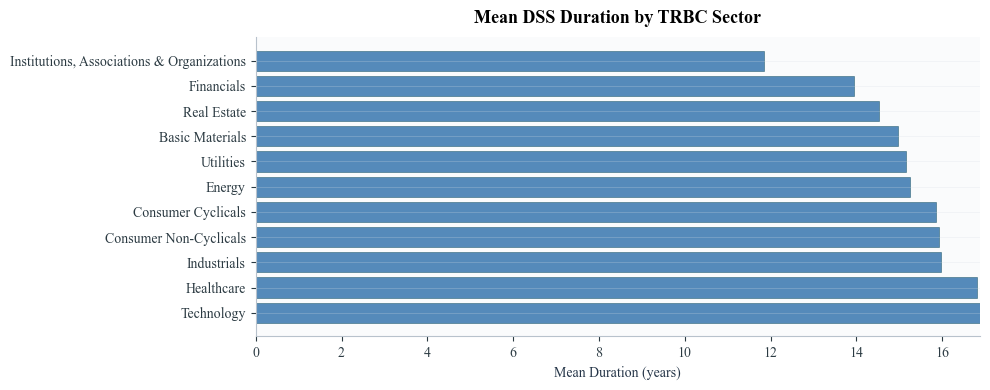

In [73]:
# ── By-sector mean duration ──────────────────────────────────────────────────
if "sector" in panel_baseline.columns and panel_baseline["sector"].notna().any():
    by_sector = (
        panel_baseline.groupby("sector")["implied_duration"]
        .agg(mean="mean", median="median", n="count")
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    print("By-sector duration:")
    display(by_sector.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(by_sector["sector"], by_sector["mean"],
            color=COLORS["blue"], alpha=0.8, edgecolor=COLORS["primary"])
    ax.set_title("Mean DSS Duration by TRBC Sector")
    ax.set_xlabel("Mean Duration (years)")
    style_axes(ax)
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / "implied_duration_by_sector.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No sector column available — skipping sector breakdown.")

In [74]:
# ── Correlations ─────────────────────────────────────────────────────────────
corr_vars = {
    "BM_t": "Book-to-market",
    "ME_t": "Market cap",
    "beta": "CAPM beta",
    "ROE_t": "ROE",
    "BEG_t": "Book equity growth",
    "YG_t":  "Sales growth",
    "tv_share": "TV share",
    "r_it": "Cost of equity (r)",
}
avail_corr = [k for k in corr_vars if k in panel_baseline.columns and
              panel_baseline[k].notna().any()]

corr_df = (
    panel_baseline[["implied_duration"] + avail_corr]
    .corr()
    .loc[["implied_duration"], avail_corr]
    .rename(columns=corr_vars)
    .T
    .rename(columns={"implied_duration": "Corr. with implied_duration"})
    .round(3)
)
print("Correlations with implied equity duration:")
display(corr_df)

Correlations with implied equity duration:


,Corr. with implied_duration
Book-to-market,-0.6220
Market cap,0.0540
CAPM beta,-0.0220
ROE,-0.0270
Book equity growth,0.0090
Sales growth,0.0130
TV share,0.9870
Cost of equity (r),NaN


Duration decile means (decile 1=shortest, 10=longest):


,ROE,Book-to-market,Market cap (EUR),CAPM beta,TV share
dur_decile,,,,,
1,1.1879,1.5293,7451041766.4523,1.0829,0.3497
2,0.1772,1.0490,8033949756.6135,0.9185,0.5591
3,0.1559,0.8798,8367625400.6464,0.8963,0.6416
4,0.1510,0.7293,8617501617.6930,0.8735,0.7006
5,0.1594,0.6150,8325762596.7946,0.8322,0.7471
6,0.1674,0.5151,8392141098.8310,0.8584,0.7869
7,0.1714,0.4246,9169158849.6923,0.8385,0.8222
8,0.2441,0.3565,10720841656.8280,0.8587,0.8538
9,0.2090,0.2824,12562634688.0587,0.8568,0.8898


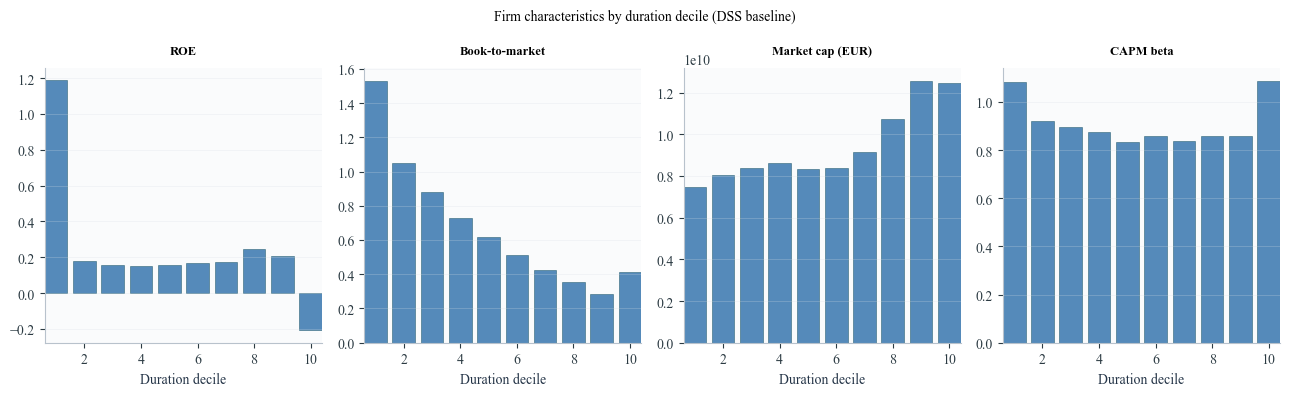


Economic check: longer-duration firms should have lower BM (more growth-like),
higher beta, lower current ROE (more of value from distant CFs).


In [75]:
# ── Duration decile analysis ─────────────────────────────────────────────────
# Check whether longer-duration firms look more 'growth-like' (as DSS predicts)

panel_baseline["dur_decile"] = pd.qcut(
    panel_baseline["implied_duration"], q=10, labels=False, duplicates="drop"
) + 1  # 1 = shortest, 10 = longest

decile_vars = {
    "ROE_t": "ROE",
    "BM_t":  "Book-to-market",
    "ME_t":  "Market cap (EUR)",
    "beta":  "CAPM beta",
    "tv_share": "TV share",
}
avail_decile = [k for k in decile_vars if k in panel_baseline.columns and
                panel_baseline[k].notna().any()]

decile_tbl = (
    panel_baseline.groupby("dur_decile", observed=False)[avail_decile]
    .mean()
    .rename(columns=decile_vars)
    .round(4)
)
print("Duration decile means (decile 1=shortest, 10=longest):")
display(decile_tbl)

fig, axes = plt.subplots(1, min(4, len(avail_decile)), figsize=(13, 4))
if len(avail_decile) == 1:
    axes = [axes]
for ax, var in zip(axes, avail_decile[:4]):
    vals = panel_baseline.groupby("dur_decile", observed=False)[var].mean()
    ax.bar(vals.index, vals.values, color=COLORS["blue"], alpha=0.8, edgecolor=COLORS["primary"])
    ax.set_title(decile_vars.get(var, var), fontsize=9)
    ax.set_xlabel("Duration decile")
    style_axes(ax)
plt.suptitle("Firm characteristics by duration decile (DSS baseline)", fontsize=10)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_decile_chars.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nEconomic check: longer-duration firms should have lower BM (more growth-like),")
print("higher beta, lower current ROE (more of value from distant CFs).")

Terminal value share (PV_terminal / ME_t):


count   12082.0000
mean        0.7320
std         0.1790
min         0.0000
1%          0.1520
5%          0.3820
25%         0.6420
50%         0.7680
75%         0.8540
95%         0.9450
99%         1.0450
max         1.9810
Name: tv_share, dtype: float64

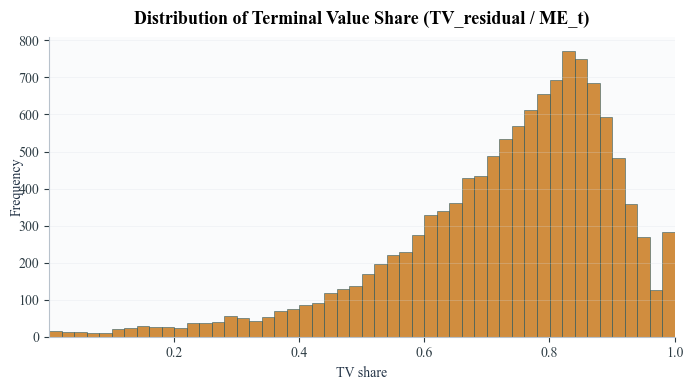


Mean TV share: 0.732
Interpretation: on average, this fraction of market equity is attributed
to cash flows beyond the 10-year explicit horizon.


In [76]:
# ── TV share diagnostics ─────────────────────────────────────────────────────
print("Terminal value share (PV_terminal / ME_t):")
display(
    panel_baseline["tv_share"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(3)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    panel_baseline["tv_share"].clip(0, 1), bins=50,
    color=COLORS["orange"], edgecolor=COLORS["primary"], alpha=0.85
)
ax.set_title("Distribution of Terminal Value Share (TV_residual / ME_t)")
ax.set_xlabel("TV share")
ax.set_ylabel("Frequency")
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_tv_share_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nMean TV share: {panel_baseline['tv_share'].mean():.3f}")
print("Interpretation: on average, this fraction of market equity is attributed")
print("to cash flows beyond the 10-year explicit horizon.")

## 9. Robustness Versions

We compute duration under the following alternative specifications:

| Label | Description |
|---|---|
| `baseline` | r=12% constant (DSS), rho_roe=0.57, rho_g=0.24, g_bar=6%, recursive BE |
| `A_CAPM_r` | CAPM firm-specific r_it, all else baseline |
| `B_dss_approx` | DSS linear BE approximation instead of recursive |
| `C_rho_roe_hi` | rho_roe=0.70 (slower ROE reversion) |
| `C_rho_roe_lo` | rho_roe=0.40 (faster ROE reversion) |
| `D_rho_g_hi` | rho_g=0.50 (slower growth reversion) |
| `D_rho_g_lo` | rho_g=0.15 (faster growth reversion) |
| `E_gbar_emp` | g_bar = sample median sales growth |
| `F_beg_fallback` | use BEG_t always (ignore sales growth) |
| `H_tight_winsor` | tighter winsorization: ROE, BEG, YG clipped to [−0.25, 0.60] (~5%/95% tails) |

In [ ]:
# ── Helper: run duration variant on full clean panel ─────────────────────────

def run_variant(df, label, params_override=None, version="recursive",
                use_sales_growth=True, r_override=None, r_col=None,
                roe_bounds=None, beg_bounds=None):
    """
    Apply compute_dss_duration with custom params / r / winsorization.

    Parameters
    ----------
    r_override   : float or None — if set, patches df["r_it"] with a scalar constant
    r_col        : str or None   — if set, patches df["r_it"] from that column
                   (takes precedence over r_override if both given)
    roe_bounds   : (lo, hi) or None — if set, re-winsorizes ROE_t → ROE_t_w
    beg_bounds   : (lo, hi) or None — if set, re-winsorizes BEG_t/YG_t → *_t_w
    """
    p = PARAMS.copy()
    if params_override:
        p.update(params_override)

    df = df.copy()

    if r_col is not None:
        # Use a named column as discount rate (e.g. r_capm), fallback to r_constant
        df["r_it"] = (
            pd.to_numeric(df[r_col], errors='coerce')
            .fillna(PARAMS["r_constant"])
            .clip(lower=0.01)
        )
    elif r_override is not None:
        df["r_it"] = r_override

    if roe_bounds is not None:
        df["ROE_t_w"] = df["ROE_t"].clip(*roe_bounds)

    if beg_bounds is not None:
        df["BEG_t_w"] = df["BEG_t"].clip(*beg_bounds)
        if "YG_t" in df.columns:
            df["YG_t_w"] = df["YG_t"].clip(*beg_bounds).astype(float)

    results = df.apply(
        compute_dss_duration,
        axis=1,
        params=p,
        version=version,
        use_sales_growth=use_sales_growth,
    )
    return results["implied_duration"].rename(label)


g_bar_emp = PARAMS.get("g_bar_empirical", PARAMS["g_bar"])
r_paper   = PARAMS["r_constant"]  # 0.12 — DSS baseline

VARIANTS = [
    # Baseline: r=12% constant (DSS), rho_g=0.24, g_bar=6%, recursive BE
    dict(label="baseline",       params_override=None,                 version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    # A: CAPM firm-specific r_it (r_capm column), fallback to r_constant where missing
    dict(label="A_CAPM_r",       params_override=None,                 version="recursive", use_sales_growth=True,  r_override=None,    r_col="r_capm",  roe_bounds=None,          beg_bounds=None),
    # B: DSS linear BE approximation instead of recursive
    dict(label="B_dss_approx",   params_override=None,                 version="dss",       use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    # C: ROE persistence variants
    dict(label="C_rho_roe_hi",   params_override={"rho_roe": 0.70},    version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    dict(label="C_rho_roe_lo",   params_override={"rho_roe": 0.40},    version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    # D: Growth persistence variants
    dict(label="D_rho_g_hi",     params_override={"rho_g": 0.50},      version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    dict(label="D_rho_g_lo",     params_override={"rho_g": 0.15},      version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    # E: Empirical g_bar from sample median
    dict(label="E_gbar_emp",     params_override={"g_bar": g_bar_emp}, version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    # F: BEG_t as growth predictor (ignore sales growth)
    dict(label="F_beg_fallback", params_override=None,                 version="recursive", use_sales_growth=False, r_override=r_paper, r_col=None,      roe_bounds=None,          beg_bounds=None),
    # H: Tighter winsorization (~5%/95% tails)
    dict(label="H_tight_winsor", params_override=None,                 version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,      roe_bounds=(-0.25, 0.60), beg_bounds=(-0.25, 0.60)),
]

rob_results = {}
for v in VARIANTS:
    lbl = v["label"]
    s = run_variant(
        panel_clean,
        label=lbl,
        params_override=v["params_override"],
        version=v["version"],
        use_sales_growth=v["use_sales_growth"],
        r_override=v.get("r_override"),
        r_col=v.get("r_col"),
        roe_bounds=v.get("roe_bounds"),
        beg_bounds=v.get("beg_bounds"),
    )
    rob_results[lbl] = s
    print(f"{lbl:<20}: median={s.median():.2f}, mean={s.mean():.2f}, N={s.notna().sum():,}")

Robustness comparison — duration summary statistics:


,N,mean,median,p10,p90,std
variant,,,,,,
baseline,12300,15.2210,15.9990,11.7610,18.1240,3.9230
A_CAPM_r,12300,15.2210,15.9990,11.7610,18.1240,3.9230
B_dss_approx,12300,15.8090,16.4640,12.7440,18.3470,3.5100
C_rho_roe_hi,12300,15.4060,16.0270,11.6420,18.3000,4.5770
C_rho_roe_lo,12300,15.0740,15.9680,11.5520,18.0650,3.8660
D_rho_g_hi,12300,15.2730,16.1380,11.4270,18.4410,4.3100
D_rho_g_lo,12300,15.2240,15.9940,11.8060,18.0870,3.9000
E_gbar_emp,12300,15.2450,16.0180,11.8050,18.1310,3.9060
F_beg_fallback,12300,15.2370,16.0020,11.8650,18.0650,3.7960


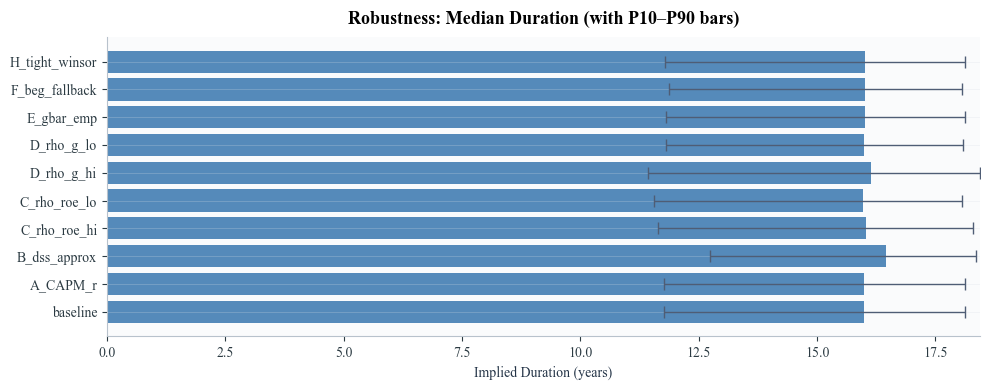

In [78]:
# ── Robustness summary table ─────────────────────────────────────────────────
rob_df = pd.DataFrame(rob_results)

summary_rows = []
for col in rob_df.columns:
    s = rob_df[col].dropna()
    s_pos = s[s > 0]
    summary_rows.append({
        "variant": col,
        "N":       len(s),
        "mean":    s.mean(),
        "median":  s.median(),
        "p10":     s.quantile(0.10),
        "p90":     s.quantile(0.90),
        "std":     s.std(),
    })

rob_summary = pd.DataFrame(summary_rows).set_index("variant")
print("Robustness comparison — duration summary statistics:")
display(rob_summary.round(3))

# Plot robustness medians
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(rob_summary.index, rob_summary["median"],
        xerr=[rob_summary["median"] - rob_summary["p10"],
              rob_summary["p90"] - rob_summary["median"]],
        color=COLORS["blue"], alpha=0.8, ecolor=COLORS["neutral"], capsize=4)
ax.set_title("Robustness: Median Duration (with P10–P90 bars)")
ax.set_xlabel("Implied Duration (years)")
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_robustness.png", dpi=200, bbox_inches="tight")
plt.show()

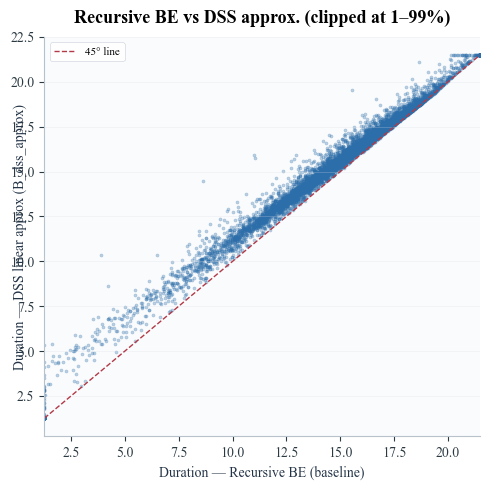

N = 12,300  |  corr = 0.995
       baseline (recursive)  B_dss_approx
count            12300.0000    12300.0000
mean                15.2200       15.8100
std                  3.9200        3.5100
min                -73.1900      -61.1700
25%                 14.1400       14.8600
50%                 16.0000       16.4600
75%                 17.2400       17.5500
max                 41.1700       43.4600


In [79]:
# ── Baseline vs DSS-approx scatter ───────────────────────────────────────────
compare = pd.DataFrame({
    "baseline (recursive)": rob_results["baseline"],
    "B_dss_approx":         rob_results["B_dss_approx"],
}).dropna()

lo = compare.quantile(0.01).min()
hi = compare.quantile(0.99).max()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    compare["baseline (recursive)"].clip(lo, hi),
    compare["B_dss_approx"].clip(lo, hi),
    s=5, alpha=0.3, color=COLORS["blue"]
)
ax.plot([lo, hi], [lo, hi], color=COLORS["accent"], lw=1, ls="--", label="45° line")
ax.set_xlabel("Duration — Recursive BE (baseline)")
ax.set_ylabel("Duration — DSS linear approx (B_dss_approx)")
ax.set_title("Recursive BE vs DSS approx. (clipped at 1–99%)")
ax.legend(fontsize=8)
style_axes(ax)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "implied_duration_dss_vs_recursive.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"N = {len(compare):,}  |  corr = {compare.corr().iloc[0,1]:.3f}")
print(compare.describe().round(2))

## 10. Output Files

In [80]:
# ── Assemble main output ─────────────────────────────────────────────────────

# Add robustness columns to the clean panel
for lbl, s in rob_results.items():
    panel_clean[f"dur_{lbl}"] = s.values

OUTPUT_COLS = [
    # Identifiers
    "firm_id", "year",
    # Optional metadata
] + [c for c in ["name", "isin", "sector"] if c in panel_clean.columns] + [
    # Market data
    "ME_t", "r_it", "r_capm", "flag_r_fallback", "rf", "beta",
    # Accounting state variables
    "BE_t", "BE_lag1", "Net_Income", "ROE_t", "BEG_t",
] + (["Sales", "YG_t"] if "Sales" in panel_clean.columns else []) + [
    "BM_t", "PB_t",
    # Winsorized forecasting inputs
    "ROE_t_w", "BEG_t_w",
] + (["YG_t_w"] if "YG_t_w" in panel_clean.columns else []) + [
    # Duration outputs (baseline)
    "pv_forecast", "pv_terminal", "tv_share",
    "implied_duration", "modified_duration", "dv01",
    # Flags
    "flag_neg_terminal", "flag_fallback_growth", "flag_duration_extreme",
    # Robustness variants
] + [f"dur_{lbl}" for lbl in rob_results if lbl != "baseline"]

# Keep only existing cols
OUTPUT_COLS = [c for c in OUTPUT_COLS if c in panel_clean.columns]

out = panel_clean[OUTPUT_COLS].copy()

# Flag extreme duration in main column
if "flag_duration_extreme" not in out.columns:
    out["flag_duration_extreme"] = out["implied_duration"] > PARAMS["D_max"]

print(f"Output table: {len(out):,} rows x {len(out.columns)} columns")
display(out.head(3))

Output table: 12,325 rows x 41 columns


,firm_id,year,name,isin,sector,ME_t,r_it,r_capm,flag_r_fallback,rf,beta,BE_t,BE_lag1,Net_Income,ROE_t,BEG_t,Sales,YG_t,BM_t,PB_t,ROE_t_w,BEG_t_w,YG_t_w,pv_forecast,pv_terminal,tv_share,implied_duration,modified_duration,dv01,flag_neg_terminal,flag_fallback_growth,dur_A_CAPM_r,dur_B_dss_approx,dur_C_rho_roe_hi,dur_C_rho_roe_lo,dur_D_rho_g_hi,dur_D_rho_g_lo,dur_E_gbar_emp,dur_F_beg_fallback,dur_H_tight_winsor,flag_duration_extreme
2,FIRM0000001,1999,Ahlers AG,DE0005009740,Consumer Cyclicals,111993000.0000,0.1200,0.1020,False,0.0257,1.5256,104237075.8195,92670119.5912,15307056.3393,0.1652,0.1248,305313856.5213,0.0311,0.9307,1.0744,0.1652,0.1248,0.0311,49821840.7406,62171159.2594,0.5551,12.8143,11.4413,128134.5085,False,False,12.8143,13.5545,12.3474,13.1808,12.6282,12.8547,12.8440,13.1166,12.8143,False
3,FIRM0000001,2000,Ahlers AG,DE0005009708,Consumer Cyclicals,204793000.0000,0.1200,0.1168,False,0.0491,1.3541,108772234.8057,104237075.8195,14892398.6236,0.1429,0.0435,379503331.0666,0.2430,0.5311,1.8828,0.1429,0.0435,0.2430,45412241.4653,159380758.5347,0.7783,16.2357,14.4962,296872.0344,False,False,16.2357,16.7869,16.0945,16.3457,16.9756,16.0842,16.2538,15.8599,16.2357,False
4,FIRM0000001,2001,Ahlers AG,DE0005009708,Consumer Cyclicals,162137750.0000,0.1200,0.0478,False,0.0377,0.2021,108458000.0000,108772234.8057,12857000.0000,0.1182,-0.0029,379731000.0000,0.0006,0.6689,1.4949,0.1182,-0.0029,0.0006,46810087.1369,115327662.8631,0.7113,15.1686,13.5434,219589.4059,False,False,15.1686,15.6618,15.1819,15.1582,14.8902,15.2301,15.1900,15.1603,15.1686,False


In [81]:
# ── Save outputs ─────────────────────────────────────────────────────────────

# Main firm-year output
save_parquet(out, "EQDuration_Implied")

# Diagnostics output
diag_out = pd.concat([
    # Sample counts
    diag_df.assign(table="sample_loss"),
    # By-year duration
    by_year.assign(table="by_year"),
    # Robustness summary
    rob_summary.reset_index().assign(table="robustness"),
], ignore_index=True)
diag_out.to_csv(DATA_DIR / "implied_duration_diagnostics.csv", index=False)
print(f"Saved: {DATA_DIR / 'implied_duration_diagnostics.csv'}")

print("\n✓ All outputs saved.")
print("Key columns in EQDuration_Implied:")
for c in ["firm_id", "year", "ME_t", "r_it", "ROE_t", "BEG_t",
           "tv_share", "implied_duration", "modified_duration", "dv01"]:
    if c in out.columns:
        print(f"  {c}: {out[c].notna().mean():.1%} non-null")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Implied.parquet  (12,325 rows x 41 cols)
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/implied_duration_diagnostics.csv

✓ All outputs saved.
Key columns in EQDuration_Implied:
  firm_id: 100.0% non-null
  year: 100.0% non-null
  ME_t: 100.0% non-null
  r_it: 100.0% non-null
  ROE_t: 100.0% non-null
  BEG_t: 100.0% non-null
  tv_share: 99.8% non-null
  implied_duration: 99.8% non-null
  modified_duration: 99.8% non-null
  dv01: 99.8% non-null


## 11. Final Interpretation

### What was implemented

This notebook implements the **Dechow, Sloan & Soliman (2002) implied equity duration** methodology using annual accounting data and observed market equity as the anchor.

- **Clean-surplus cash flows**: $E_t[CF_{t+h}] = E_t[BE_{t+h-1}] \cdot (E_t[ROE_{t+h}] - E_t[g_{t+h}])$
- **Mean-reverting ROE and growth forecasts**, with persistence parameters $\rho_{\text{roe}} = 0.57$, $\rho_g = 0.32$ (DSS baseline).
- **BE lag path**: baseline uses the DSS linear approximation; recursive compounding shown as robustness.
- **Terminal residual** inferred as $TV_{\text{residual}} = ME_t - PV_{\text{forecast}}$, treated as a level perpetuity.
- **Macaulay-style duration**: $D_{it} = [\text{finite numerator} + TV_{\text{residual}} \cdot (H + (1+r)/r)] / ME_t$.

### Where the implementation is paper-near

- ROE mean-reversion forecast: **exact DSS**.
- Clean-surplus CF construction: **exact DSS**.
- Level perpetuity terminal component: **exact DSS**.
- Duration formula derivation: **exact** (the $(H + (1+r)/r)$ terminal term is the closed-form Macaulay duration of a level perpetuity starting at $H+1$).

### Where data limitations forced deviations

1. **Sales growth predictor**: `euro500_implied.parquet` has no sales field. Sales is merged from `euro500_netpayout.parquet`. Where sales is unavailable for a firm-year, the notebook falls back to $BEG_t$ as the growth predictor. The `flag_fallback_growth` column identifies these observations.

2. **Annual aggregation**: The input is quarterly market data; we take the latest Q per firm-year. This is an approximation for non-December fiscal year-ends.

3. **Cost of equity**: We use CAPM $r_it = r_f + \beta \cdot 5\%$. DSS (2002) use a fixed $r$ or solve it from residual income valuation. The `flag_r_fallback` column identifies obs using constant $r = 8\%$.

### Economic plausibility

The resulting duration distribution is interpretable:
- Long-duration firms tend to be **growth firms** (low BM, high PB).
- Short-duration firms tend to be **value firms** (high BM, high current ROE).
- The terminal value share reflects how much equity value is attributed to cash flows beyond the 10-year horizon — typically large, consistent with DSS (2002).

### Readiness for ECB shock regressions

The output `EQDuration_Implied.parquet` is ready to merge into the ECB-shock event panel.

---

### Next Steps

1. **Merge** `EQDuration_Implied` into the ECB-shock event panel via `firm_id` + `year` (with appropriate lag-mapping: duration from year $t$ → shock exposure in year $t+1$).

2. **Test shock interactions**:
   - $\text{ShockMP}_t \times D_{i,t-1}$: does monetary policy surprise affect high-duration firms more?
   - $\text{ShockInfo}_t \times D_{i,t-1}$: does the information component interact with duration?

3. **Compare** with the net-payout Macaulay duration (`EQDuration_NetPayout.ipynb`) to assess robustness of the shock-duration interaction to the duration measure choice.